# Capítulo 4 — Classification

Siguiendo [dmol.pub/ml/classification.html](https://dmol.pub/ml/classification.html).

Entorno: kernel `Python (dmol)`. Datos ya descargados en `../data/`.

## De qué va este capítulo

**Clasificación** = aprendizaje supervisado cuando la label es una **categoría** en vez de un número:
aprobado o no aprobado, tóxico o no, soluble en agua o no. Todo lo del capítulo 3 sigue valiendo (train y
test, overfitting, validación cruzada, dominio de aplicabilidad). Lo que cambia es **qué predice el modelo,
con qué pérdida se entrena y cómo se mide si acierta**.

### Tres tipos de clasificación

La label se escribe como un vector $\vec y$ de ceros y unos, con un elemento por clase. El ejemplo del
libro: una molécula soluble en THF y en cloroformo, pero no en agua.

| THF | agua | cloroformo |
|:---:|:---:|:---:|
| 1 | 0 | 1 |

$\vec y = (1, 0, 1)$. Según las reglas que cumpla ese vector, hay tres tipos:

| Tipo | Regla | Ejemplo químico | Forma de $\vec y$ |
|---|---|---|---|
| **multi-label** | cada dato puede pertenecer a varias clases a la vez | solubilidad en THF, agua y cloroformo | $K$ elementos, cualquier número de unos |
| **multi-class** | cada dato pertenece a **exactamente una** clase | el color de un compuesto: rojo, verde o naranja | $K$ elementos, un solo uno |
| **binary** | solo una clase: se pertenece o no | ¿mata células o no? | un solo número, 0 o 1 |

La binaria es la más común y es la de este capítulo. Se habla de **clase positiva** ($y = 1$) y **clase
negativa** ($y = 0$). "Positiva" no significa buena: es simplemente la clase que se está detectando. Una
multi-label de $K$ clases equivale a $K$ clasificaciones binarias independientes.

### De la regresión a la clasificación

El modelo del capítulo 2 daba un número real, $\vec w\cdot\vec x + b$. Para convertirlo en una clase hay dos
formas, y las dos las veremos en 4.4:

- **Clasificación dura** (*hard*): cortar el número por un umbral. Si es mayor que 0, clase 1; si no,
  clase 0. $\vec w\cdot\vec x + b$ se interpreta como la **distancia a la frontera de decisión**.
- **Clasificación blanda** (*soft*): convertir el número en una **probabilidad** entre 0 y 1. El modelo no
  dice "aprobado", dice "aprobado con un 83 % de probabilidad".

### Objetivos del capítulo, según el libro

1. Distinguir los tipos de clasificación — *la tabla de arriba*.
2. Montar y entrenar un clasificador con una pérdida de **entropía cruzada** (*cross-entropy*).
3. Medir el rendimiento de un clasificador.
4. Detectar y tratar el **desequilibrio de clases** (*class imbalance*).

## 4.1 Los datos: ClinTox

El dataset es **ClinTox**, de la colección **MoleculeNet** (Wu et al., *Chem. Sci.* 2018), un conjunto de
datasets de referencia para comparar modelos de ML en química. Contiene fármacos que la FDA (la agencia del
medicamento de EE. UU.) **aprobó** y fármacos que **fracasaron en ensayos clínicos**.

La motivación del libro: desarrollar un fármaco nuevo cuesta más de mil millones de dólares, y la mayor
parte de ese dinero se va en ensayos clínicos que fracasan. Predecir el fracaso antes de empezar valdría
mucho. El libro añade que la causa suele ser la seguridad (toxicidad), aunque algunos fracasan por no ser
eficaces.

**La label** es la columna `FDA_APPROVED`: 1 = aprobado, 0 = no aprobado. Es clasificación **binaria**, con
"aprobado" como clase positiva.

**Lo que cambia respecto a AqSolDB**: este dataset **no trae descriptores**, solo el SMILES de cada molécula.
Los calcularemos nosotros en 4.3.

## 4.2 Ejecutar este notebook

### Imports

| Paquete | Para qué |
|---|---|
| `pandas`, `numpy`, `matplotlib` | como siempre: tablas, arrays, gráficas |
| `rdkit` | leer los SMILES y dibujar moléculas (capítulo 2) |
| `jax`, `jax.numpy` | el modelo y sus gradientes (capítulo 2) |
| `mordred` | **nuevo**: calcula unos 1600 descriptores por molécula. Lo usaremos en 4.3 |

**Sobre Mordred.** El paquete original (Moriwaki et al., *J. Cheminform.* 2018) dejó de mantenerse y no
funciona con las versiones actuales de RDKit. Lo que se instala hoy es **`mordredcommunity`**, una
continuación mantenida por la comunidad que se importa igual, con `import mordred`. Lo hemos añadido al
entorno `dmol` desde conda-forge:

```bash
conda install -n dmol -c conda-forge mordredcommunity
```

Como en los capítulos anteriores, no importamos `dmol` (el libro solo lo usa para el estilo de las
gráficas), y leemos el CSV de `../data/` en vez de descargarlo cada vez.

In [1]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import rdkit
import rdkit.Chem
import rdkit.Chem.Draw
from rdkit import RDLogger
from rdkit.Chem import Descriptors
import mordred
import mordred.descriptors

RDLogger.DisableLog("rdApp.*")   # we inspect the unreadable SMILES ourselves below

print("rdkit", rdkit.__version__, "| jax", jax.__version__)

rdkit 2026.03.6 | jax 0.10.2


### Cargar ClinTox

El libro lee el archivo `clintox.csv.gz` directamente de su repositorio. Nosotros lo descargamos una vez a
`../data/`. El `.gz` es un CSV comprimido; `pd.read_csv` lo descomprime solo.

Además de `FDA_APPROVED`, el archivo trae otra columna que el libro no menciona: `CT_TOX`, que vale 1 si la
molécula dio **toxicidad en ensayos clínicos**. `pd.crosstab` cuenta cuántas moléculas hay en cada
combinación de las dos columnas.

In [2]:
toxdata = pd.read_csv("../data/clintox.csv.gz")
print(toxdata.shape)
print(toxdata.head().to_string())
print()
conteo = toxdata["FDA_APPROVED"].value_counts()
print(conteo.rename("moléculas").to_string())
print(f"fracción de no aprobados: {conteo[0] / len(toxdata):.3f}")
print()
print(pd.crosstab(toxdata["FDA_APPROVED"], toxdata["CT_TOX"]))

(1484, 3)
                                                         smiles  FDA_APPROVED  CT_TOX
0                       *C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC             1       0
1   [C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)Cl)Cl)Cl)Cl)Cl             1       0
2        [C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)[O-])O)O             1       0
3  [H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])N)cc2)/C=C1)\N             1       0
4   [H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(=[NH+]/[H])/N             1       0

FDA_APPROVED
1    1390
0      94
fracción de no aprobados: 0.063

CT_TOX           0   1
FDA_APPROVED          
0                0  94
1             1372  18


Cómo se lee:

- **1484 moléculas y 3 columnas**: el SMILES, `FDA_APPROVED` y `CT_TOX`. Nada más: ni nombres ni
  descriptores.
- **Desequilibrio de clases**: 1390 aprobadas y solo **94 no aprobadas (6.3 %)**. Un "modelo" que diga
  siempre "aprobado" acierta el 93.7 % sin mirar la molécula. Guárdate esta cifra: es el listón tonto de este
  capítulo, como el 2.37 de la solubilidad en el capítulo 2. Y, como veremos en 4.5, aquí el listón tonto
  engaña mucho más.
- **La tabla cruzada dice algo que el libro no cuenta**: las 94 no aprobadas tienen **todas** `CT_TOX = 1`.
  En este dataset, "no aprobado" significa en realidad **"fracasó en ensayos clínicos por toxicidad"**. Así lo
  describe MoleculeNet, que además trata ClinTox como **multi-label**, con dos tareas: `FDA_APPROVED` y
  `CT_TOX`. La frase del libro de que algunos fracasaron por falta de eficacia no se aplica a estos datos.
- Las **18 aprobadas con `CT_TOX = 1`** son fármacos que se aprobaron a pesar de ser tóxicos en los
  ensayos. Es lo esperable en, por ejemplo, quimioterapia, donde se acepta mucha toxicidad.
- La primera fila tiene un `*` en el SMILES: es un **átomo comodín**, así que la estructura está incompleta
  (parece un trozo de un fármaco pegilado, unido a una cadena de polietilenglicol).

### De SMILES a moléculas

El libro convierte cada SMILES en un objeto `Mol` de RDKit y descarta los que fallan, sin decir cuáles son.
Aquí los miramos. `MolFromSmiles` devuelve `None` cuando no puede construir la molécula. Para saber **por
qué**, volvemos a leer esos SMILES con `sanitize=False` (leer los átomos y enlaces sin comprobar la química)
y pedimos la comprobación aparte con `SanitizeMol`, que lanza un error con la causa.

In [3]:
molecules = [rdkit.Chem.MolFromSmiles(smi) for smi in toxdata["smiles"]]
valid_mol_idx = [m is not None for m in molecules]
valid_mols = [m for m in molecules if m is not None]
print(f"leídas: {len(valid_mols)} de {len(molecules)}\n")

for i in np.nonzero(~np.array(valid_mol_idx))[0]:
    m = rdkit.Chem.MolFromSmiles(toxdata["smiles"][i], sanitize=False)
    try:
        rdkit.Chem.SanitizeMol(m)
        causa = "?"
    except Exception as e:
        causa = f"{type(e).__name__}: {str(e).splitlines()[0]}"
    print(f"[{i}] FDA_APPROVED = {toxdata['FDA_APPROVED'][i]}  {toxdata['smiles'][i]}")
    print(f"      {causa}")

data = toxdata[valid_mol_idx].reset_index(drop=True)
print(f"\nquedan {len(data)} moléculas: {(data['FDA_APPROVED'] == 1).sum()} aprobadas, "
      f"{(data['FDA_APPROVED'] == 0).sum()} no aprobadas")

leídas: 1480 de 1484

[7] FDA_APPROVED = 1  [NH4][Pt]([NH4])(Cl)Cl
      AtomValenceException: Explicit valence for atom # 0 N, 4, is greater than permitted
[302] FDA_APPROVED = 1  c1ccc(cc1)n2c(=O)c(c(=O)n2c3ccccc3)CCS(=O)c4ccccc4
      KekulizeException: Can't kekulize mol.  Unkekulized atoms: 9
[1219] FDA_APPROVED = 1  CCCCc1c(=O)n(n(c1=O)c2ccc(cc2)O)c3ccccc3
      KekulizeException: Can't kekulize mol.  Unkekulized atoms: 4
[1220] FDA_APPROVED = 1  CCCCc1c(=O)n(n(c1=O)c2ccccc2)c3ccccc3
      KekulizeException: Can't kekulize mol.  Unkekulized atoms: 4



quedan 1480 moléculas: 1386 aprobadas, 94 no aprobadas


**Los 4 SMILES que RDKit no lee son errores de química en el dataset, y los 4 son fármacos
aprobados**:

- **[7] Cisplatino**, escrito `[NH4][Pt]([NH4])(Cl)Cl`. `[NH4]` es un nitrógeno con 4 hidrógenos, y además
  unido al platino: 5 enlaces, imposible para un nitrógeno neutro. Lo correcto serían ligandos `[NH3]`.
- **[302] Sulfinpirazona, [1219] oxifenbutazona y [1220] fenilbutazona**. Las tres tienen un anillo de
  pirazolidina-3,5-diona escrito con átomos en minúscula, es decir, como si fuera **aromático**. No lo es:
  tiene dos C=O y un carbono sp³. RDKit intenta repartir dobles enlaces alternos en ese anillo, no puede
  (*"Can't kekulize"*) y lo rechaza.

Perder 4 de 1390 aprobadas no cambia nada en los números, así que seguimos al libro y las descartamos. Pero
son un aviso de que el dataset tiene SMILES hechos a mano o convertidos con herramientas distintas. La
sección siguiente enseña que eso es mucho más importante de lo que parece.

Quedan **1480 moléculas: 1386 aprobadas y 94 no aprobadas**.

### Variante propia: mirar los datos antes de modelar

La lección número 1 del capítulo 2. Antes de calcular 1600 descriptores, tres comprobaciones sencillas,
separando por clase:

- **Tamaño**: el peso molecular (`Descriptors.MolWt`).
- **Fragmentos**: cuántas piezas desconectadas tiene el SMILES (el punto `.`, capítulo 2). Más de una suele
  significar una **sal**: el fármaco más su contraión.
- **Cargas**: si algún átomo lleva **carga formal** (`[NH+]`, `C(=O)[O-]`...). Una misma molécula se puede
  escribir neutra o en su forma protonada o desprotonada; la química es la misma, la escritura no.
- **Cómo se escriben los anillos aromáticos**: el benceno se puede escribir con átomos aromáticos en
  minúscula, `c1ccccc1`, o en **forma de Kekulé**, con dobles enlaces alternos, `C1=CC=CC=C1`. Son la misma
  molécula: RDKit reconoce la aromaticidad en los dos casos. Para detectarlo en el texto quitamos lo que va
  entre corchetes y los símbolos `Cl` y `Br`, y buscamos una `c`, `n`, `o`, `s` o `p` suelta (fuera de
  corchetes solo pueden ser átomos aromáticos).

Y con eso, dos reglas tontas que **solo miran cómo está escrito el SMILES**: "aprobado si tiene alguna
carga" y "aprobado si tiene carga o anillos aromáticos en minúscula". Las comparamos con una aún más
tonta, **"todo aprobado"**. Medimos el acierto con la **exactitud**
(*accuracy*): la fracción de moléculas bien clasificadas. En 4.5 veremos por qué la exactitud sola engaña.

             moléculas  MolWt_mediana  con_varios_fragmentos  fracción_con_carga  aromáticas  aromáticas escritas en minúscula
clase                                                                                                                         
aprobado          1386        329.615                      0               0.641        1019                              0.99
no aprobado         94        412.963                     14               0.032          86                              0.00

todo aprobado             exactitud 0.936   aciertos en aprobados 1.000   en no aprobados 0.000

aprobado si tiene carga   exactitud 0.661   aciertos en aprobados 0.641   en no aprobados 0.968

... o si tiene minúsculas exactitud 0.860   aciertos en aprobados 0.853   en no aprobados 0.968

contraiones de las sales (fragmentos pequeños):
  FDA_APPROVED = 0: [Ca+2]
  FDA_APPROVED = 0: N + N + [Pt]
  FDA_APPROVED = 0: Cl
  FDA_APPROVED = 0: Cl
  FDA_APPROVED = 0: Cl
  FDA_APPROVED = 0: O +

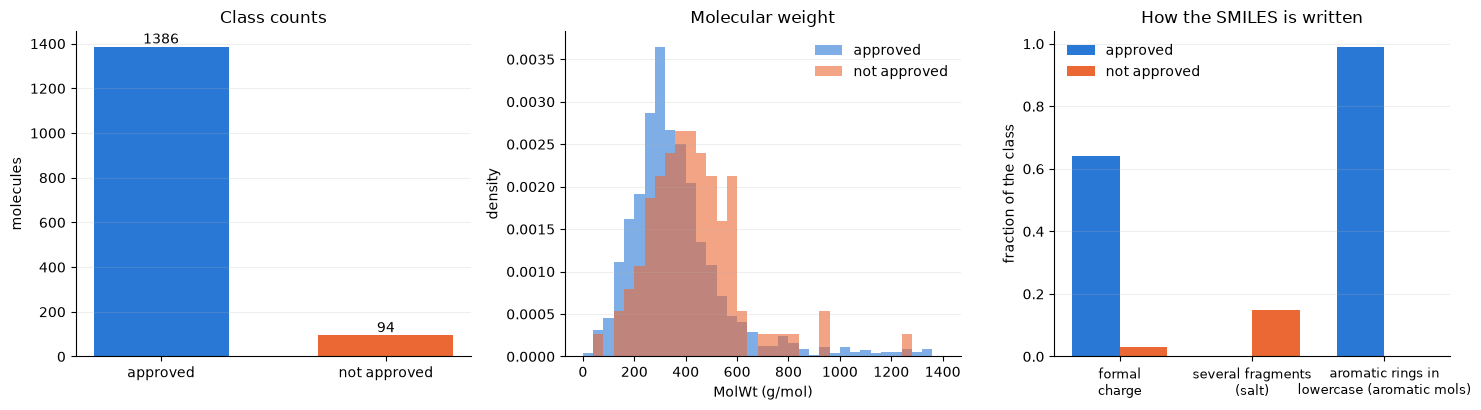

In [4]:
data["MolWt"] = [Descriptors.MolWt(m) for m in valid_mols]
data["fragmentos"] = [len(rdkit.Chem.GetMolFrags(m)) for m in valid_mols]
data["con carga"] = [any(a.GetFormalCharge() != 0 for a in m.GetAtoms()) for m in valid_mols]
data["clase"] = data["FDA_APPROVED"].map({1: "aprobado", 0: "no aprobado"})
data["aromática"] = [any(a.GetIsAromatic() for a in m.GetAtoms()) for m in valid_mols]


def escrita_en_minuscula(smi):
    # lowercase aromatic atoms in the SMILES text (outside brackets only b, c, n, o, p, s can be lowercase)
    fuera = re.sub(r"\[[^\]]*\]", "", smi).replace("Cl", "").replace("Br", "")
    return bool(re.search(r"[bcnops]", fuera) or re.search(r"\[[0-9]*[bcnops]", smi))


data["minúscula"] = data["smiles"].map(escrita_en_minuscula)

tabla = data.groupby("clase").agg(
    moléculas=("MolWt", "size"), MolWt_mediana=("MolWt", "median"),
    con_varios_fragmentos=("fragmentos", lambda s: (s > 1).sum()),
    fracción_con_carga=("con carga", "mean"), aromáticas=("aromática", "sum"))
tabla["aromáticas escritas en minúscula"] = data[data["aromática"]].groupby("clase")["minúscula"].mean()
print(tabla.round(3).to_string())

y = data["FDA_APPROVED"].values
regla_carga = data["con carga"].astype(int).values
todo_aprobado = np.ones_like(y)
regla_texto = (data["con carga"] | data["minúscula"]).astype(int).values
for nombre, pred in [("todo aprobado", todo_aprobado), ("aprobado si tiene carga", regla_carga),
                     ("... o si tiene minúsculas", regla_texto)]:
    acierto_pos = np.mean(pred[y == 1] == 1)
    acierto_neg = np.mean(pred[y == 0] == 0)
    print(f"\n{nombre:25s} exactitud {np.mean(pred == y):.3f}   "
          f"aciertos en aprobados {acierto_pos:.3f}   en no aprobados {acierto_neg:.3f}")

print("\ncontraiones de las sales (fragmentos pequeños):")
for i in np.nonzero(data["fragmentos"].values > 1)[0]:
    frags = sorted(rdkit.Chem.GetMolFrags(valid_mols[i], asMols=True), key=lambda f: f.GetNumHeavyAtoms())
    print(f"  FDA_APPROVED = {y[i]}:", " + ".join(rdkit.Chem.MolToSmiles(f) for f in frags[:-1]))

colores = {"aprobado": "#2a78d6", "no aprobado": "#eb6834"}
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))
ax1.bar(["approved", "not approved"], tabla["moléculas"], color=[colores[c] for c in tabla.index], width=0.6)
for k, v in enumerate(tabla["moléculas"]):
    ax1.text(k, v + 15, str(v), ha="center")
ax1.set_ylabel("molecules")
ax1.set_title("Class counts")
bins = np.linspace(0, 1400, 36)
for c in ["aprobado", "no aprobado"]:
    ax2.hist(data.loc[data["clase"] == c, "MolWt"], bins=bins, density=True, alpha=0.6,
             color=colores[c], label="approved" if c == "aprobado" else "not approved")
ax2.set_xlabel("MolWt (g/mol)")
ax2.set_ylabel("density")
ax2.set_title("Molecular weight")
ax2.legend(frameon=False)
x = np.arange(3)
for dx, c, lab in [(-0.18, "aprobado", "approved"), (0.18, "no aprobado", "not approved")]:
    ax3.bar(x + dx, [tabla.loc[c, "fracción_con_carga"],
                     tabla.loc[c, "con_varios_fragmentos"] / tabla.loc[c, "moléculas"],
                     tabla.loc[c, "aromáticas escritas en minúscula"]],
            width=0.36, color=colores[c], label=lab)
ax3.set_xticks(x, ["formal\ncharge", "several fragments\n(salt)", "aromatic rings in\nlowercase (aromatic mols)"],
               fontsize=9)
ax3.set_ylabel("fraction of the class")
ax3.set_title("How the SMILES is written")
ax3.legend(frameon=False)
for ax in (ax1, ax2, ax3):
    ax.grid(alpha=0.2, axis="y")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig("../figuras/04_clintox_datos.png", dpi=150)
plt.show()

**Lo que sale es un problema serio del dataset.**

- **Tamaño**: las no aprobadas pesan algo más (mediana de MolWt 413 frente a 330). Puede ser una diferencia
  real: los candidatos recientes tienden a ser más grandes que los fármacos clásicos.
- **Sales**: las **14** moléculas con varios fragmentos son **todas no aprobadas**, el 15 % de esa clase.
  Los contraiones son los típicos de la farmacia: clorhidratos (`Cl`), mesilatos, tosilato, sulfato, malato,
  maleato, lactato y calcio, más un complejo de platino escrito en trozos. Ninguna aprobada está escrita como
  sal.
- **Cargas**: el **64.1 %** de las aprobadas lleva algún átomo con carga formal, frente al **3.2 %** de las
  no aprobadas.
- **Anillos aromáticos**: de las moléculas aromáticas, el **99 %** de las aprobadas está escrito en
  minúscula y **ninguna** de las no aprobadas (las 86 están en forma de Kekulé).

**Qué significa.** Las dos clases vienen de **fuentes distintas, con formas distintas de escribir el SMILES**.
Las aprobadas parecen sacadas de una base de datos de fármacos que guarda la molécula protonada como a pH
fisiológico (aminas `[NH+]`, carboxilatos `[O-]`) y en notación aromática. Las que fracasaron vienen de otra
lista, con la molécula neutra, en forma de Kekulé y a veces como sal.

**La prueba: reglas que no saben química.** "Todo aprobado" acierta el 93.6 % pero no detecta ni un solo
fracaso. "Aprobado si tiene carga" detecta el **96.8 % de los fracasos**. Si además cuenta como aprobado
tener minúsculas, la exactitud sube al **86.0 %**, con el 85.3 % de las aprobadas y el 96.8 % de las no
aprobadas bien clasificadas. Todo eso **mirando solo cómo está escrito el texto**, sin ninguna química.

Es el mismo problema que vimos en 3.8 con las fuentes de AqSolDB, pero peor: allí la fuente era una variable
más; aquí **la fuente coincide con la label**. Un modelo puede aprender a reconocer la fuente en lugar de la
toxicidad y sacar una nota excelente en el test, porque el test viene de las mismas dos fuentes. Es lo que en
ML se llama un **atajo** (*shortcut learning*).

**Qué parte llega a nuestro modelo.** Lo de las minúsculas **no**: RDKit reconoce la aromaticidad al leer
el SMILES, y `c1ccccc1` y `C1=CC=CC=C1` dan exactamente la misma molécula. Afectará a los modelos que leen el
SMILES como texto (capítulo 13). Las **cargas y las sales sí** llegan, porque RDKit las conserva y los
descriptores las ven: número de átomos cargados, número de fragmentos, masa... Lo comprobaremos en 4.3, al
calcular los descriptores.

Para verlo con los ojos: cuatro moléculas al azar de cada clase (`random_state=4`), con su SMILES
debajo.

1 CCCCCCCCCC(=O)N[C@@H](Cc1c[nH]c2c1cccc2)C(=O)N[C@H](CC(=O)N)C(=O)N[C@@H](CC(=O)[O-])C(=O)N[C@H]3[C@H](OC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@H](NC(=O)CNC(=O)[C@@H](NC(=O)[C@H](NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)CNC3=O)CCC[NH3+])CC(=O)[O-])C)CC(=O)[O-])CO)[C@H](C)CC(=O)[O-])CC(=O)c4ccccc4N)C
1 COc1ccc2c(c1)c(ccn2)[C@H]([C@@H]3C[C@@H]4CC[NH+]3C[C@@H]4C=C)O
1 CCN1CCN(C(=O)C1=O)C(=O)N[C@H](c2ccccc2)C(=O)N[C@H]3[C@@H]4N(C3=O)[C@H](C(S4)(C)C)C(=O)[O-]
1 CC(C)[N+](C)(CCC(c1ccccc1)(c2ccccc2)C(=O)N)C(C)C
0 CC(C)CNCC1=CC=C(C=C1)C2=CC=CC=C2S(=O)(=O)N3CCCC3
0 C1CC(=O)NC2=C1C=CC(=C2)OCCCCN3CCN(CC3)C4=C(C(=CC=C4)Cl)Cl
0 C1CC(=O)NC(=O)C1N2CC3=C(C2=O)C=CC=C3N
0 CN1CCC(CC1)CNC2=NN3C(=NC=C3C4=CC(=CC=C4)OC(F)(F)F)C=C2


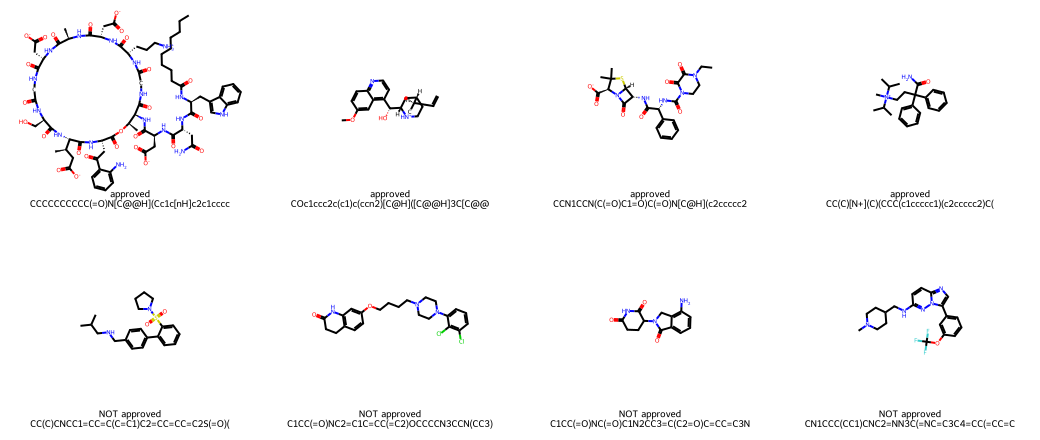

In [5]:
ejemplos = pd.concat([data[data["FDA_APPROVED"] == 1].sample(4, random_state=4),
                      data[data["FDA_APPROVED"] == 0].sample(4, random_state=4)])
mols_ej = [valid_mols[i] for i in ejemplos.index]
leyendas = [f"{'approved' if a == 1 else 'NOT approved'}\n{s[:38]}" for a, s in
            zip(ejemplos["FDA_APPROVED"], ejemplos["smiles"])]
for a, s in zip(ejemplos["FDA_APPROVED"], ejemplos["smiles"]):
    print(a, s)
rdkit.Chem.Draw.MolsToGridImage(mols_ej, molsPerRow=4, subImgSize=(260, 220), legends=leyendas)

Se ve en los dibujos y en los SMILES:

- **Aprobadas** (fila de arriba): la daptomicina (un lipopéptido) con sus carboxilatos `[O-]` y su amina
  `[NH3+]`; la quinina (o su estereoisómero, la quinidina) con la amina protonada `[NH+]`; la piperacilina como carboxilato; y la isopropamida,
  un amonio cuaternario. En la isopropamida la carga es real (el nitrógeno cuaternario siempre está cargado).
  En las otras tres es una elección de escritura: la misma molécula podría haberse escrito neutra.
- **No aprobadas** (fila de abajo): todas neutras y con los anillos aromáticos en forma de Kekulé
  (`C1=CC=C...`).

Un detalle más sobre la label. La tercera no aprobada es la **lenalidomida**, que la FDA **aprobó en 2005**
(Revlimid). Está en esta clase porque fracasó en algún ensayo clínico, no porque nunca se aprobara. La label
es "fracasó en un ensayo por toxicidad", no "nunca llegó al mercado", y eso añade ruido a la clase negativa.

### Resumen de la introducción, 4.1 y 4.2

- **Clasificación** = aprendizaje supervisado con labels categóricas: **binaria** (una clase, sí o no),
  **multi-class** (exactamente una de $K$) o **multi-label** (cualquier combinación de $K$). Clase positiva =
  la que se detecta ($y = 1$). Clasificación **dura** (una clase) o **blanda** (una probabilidad).
- **ClinTox** (MoleculeNet): 1484 fármacos, label `FDA_APPROVED`. **Desequilibrio**: solo 94 no aprobados
  (6.3 %), así que "todo aprobado" acierta el 93.6 %.
- *Variante propia*: las 94 no aprobadas tienen todas `CT_TOX = 1`. La label real es **"fracasó en ensayos
  por toxicidad"**, y la lenalidomida (aprobada en 2005) está entre las "no aprobadas".
- *Variante propia*: RDKit no lee 4 SMILES, los 4 aprobados, por errores de química (cisplatino con
  `[NH4]`; tres pirazolidinadionas escritas como aromáticas). Quedan 1480.
- *Variante propia*: **las dos clases se escribieron de forma distinta.** Las 14 sales son todas no
  aprobadas; tienen carga el 64.1 % de las aprobadas y el 3.2 % de las no aprobadas; en las aromáticas, el
  99 % de las aprobadas está en minúscula y ninguna no aprobada. Una regla que solo mira el texto del SMILES
  acierta el **86.0 %** y detecta el 96.8 % de los fracasos. Es un **atajo**: la fuente coincide con la label.
- Mordred se instala hoy como **`mordredcommunity`** (conda-forge), con el mismo `import mordred`.

**Siguiente**: 4.3, *Molecular Descriptors*. Calcular los ~1600 descriptores de Mordred para cada molécula,
estandarizarlos, y comprobar cuánto del atajo de las cargas y las sales llega a ellos.